In [344]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.compose import ColumnTransformer

In [350]:
# Step 1 - Loading a CSV file :
file_name = None

if file_name is None:
    file_name = 'IRIS'

file_name_for_read_csv = (f'{file_name}.csv')
original = pd.read_csv(file_name_for_read_csv)

if file_name == 'IRIS': original = original.drop('species', axis=1)

In [356]:
df = original.copy()

numeric_features = [col for col in df.columns if df[col].dtype in [float, int]]
categorical_features = [col for col in df.columns if col not in numeric_features]

# Before performing get_dummies, the user will confirm the features in both lists.

df = pd.get_dummies(df, columns= categorical_features, drop_first=True)
df

# scaleing for numerical features only:
scale_num_only = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features)
    ],
    remainder='passthrough' 
)
df_scaled = pd.DataFrame(scale_num_only.fit_transform(df), columns=df.columns)
df_scaled

,Age,Person Income,Employee Experience,Loan Amount,Loan interest Rate,Loan percentage,Credit History,Credit Score,Loan Status,Gender_male,...,Education_Master,Home Onwership_OTHER,Home Onwership_OWN,Home Onwership_RENT,Loan Intent_EDUCATION,Loan Intent_HOMEIMPROVEMENT,Loan Intent_MEDICAL,Loan Intent_PERSONAL,Loan Intent_VENTURE,Previous Loan_Yes
0,-0.953538,-0.104090,-0.892284,4.024953,1.683039,4.016394,-0.739109,-1.419814,1.870829,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,-1.118963,-0.846005,-0.892284,-1.359209,0.044782,-0.684829,-0.996863,-2.549975,-0.534522,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,-0.457264,-0.844065,-0.397517,-0.646600,0.625557,3.443074,-0.739109,0.047412,1.870829,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,-0.788113,-0.007039,-0.892284,4.024953,1.417829,3.443074,-0.996863,0.840507,1.870829,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4,-0.622689,-0.176371,-0.727362,4.024953,1.095549,4.475050,-0.481354,-0.924130,1.870829,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,-0.126414,-0.402231,0.097249,0.857799,1.562184,1.952442,-0.739109,0.245686,1.870829,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
44996,1.527834,-0.180537,1.911393,-0.092348,1.028407,0.003155,1.322928,-0.230171,1.870829,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
44997,0.866135,-0.290681,0.262171,-1.078758,-0.331212,-1.028821,1.065174,0.701716,1.870829,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
44998,0.204436,-0.586348,-0.232595,0.382726,0.746412,2.525762,0.034155,-0.567237,1.870829,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0


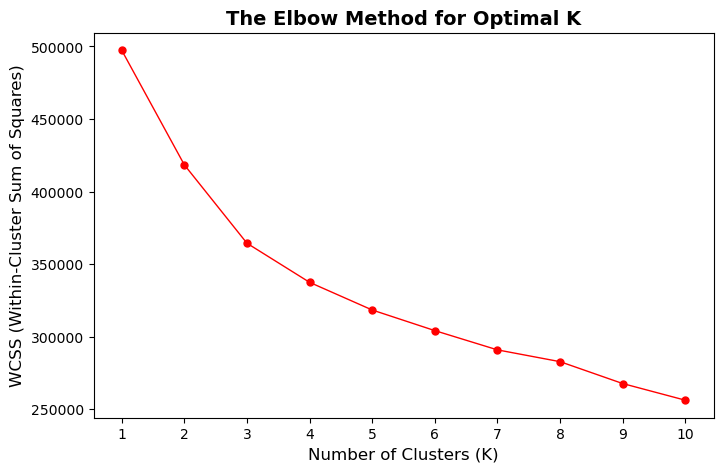

In [357]:
# Step 2 - Elbow graph: K : WCSS  

# 1. Get K-range from the user.
k_min = 1
k_max = 10

# 2. Create an empty list to store the WCSS values
wcss = []

# 3. Run KMeans for 1 to 10 clusters
for i in range(k_min, k_max+1):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=5)
    kmeans.fit(df_scaled)
    # .inertia_ gives the WCSS for that model
    wcss.append(kmeans.inertia_)

# 4. Plot the Elbow Graph
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, 'ro-', linewidth=1, markersize=5)

# 5. Add titles and labels
plt.title('The Elbow Method for Optimal K', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=12)

# Make sure all numbers from 1 to 10 show up on the X-axis
plt.xticks(range(1, 11))

# Display the graph
plt.show()

In [358]:
# Step 3 - Choosing K, running K-Means and displaying results:
k = 3

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(df_scaled) 

step_3 = pd.DataFrame({'cluster_id': df['cluster'].unique(),
'count': df.groupby('cluster').size(),
'name': None, 
'description': None})

step_3 = step_3.reset_index()
step_3

,cluster,cluster_id,count,name,description
0,0,2,29732,None,None
1,1,0,6084,None,None
2,2,1,9184,None,None


In [359]:
# Step 4- Displaying averages and common values; assigning names and descriptions using an LLM :
step_4 = original.copy()
step_4['cluster'] = df['cluster']                              # Adding a cluster number column
step_4 = step_4.groupby('cluster').mean(numeric_only=True)     # Average of numeric columns per cluster    
step_4.columns = [f"{col}_mean" for col in step_4.columns]     # Adding "mean" to the names of numeric columns
step_4.insert(0, 'count', df.groupby('cluster').size())        # Adding a count column

table_1 = step_4.copy()                                        # DataFrame for displaying average values

# Calculating common values for categorical columns:
step_4_2 = original.copy()
step_4_2['cluster'] = df['cluster']
for column in step_4_2.columns:
    if column in categorical_features:
        step_4[f'{column}_most_common'] = step_4_2.groupby('cluster')[column].agg(lambda x: x.mode().iat[0])


# DataFrame for displaying frequent values for categorical columns:
table_2 = step_4.drop(columns=step_4.select_dtypes(include=[np.number]).columns)  

table_2

,Gender_most_common,Education_most_common,Home Onwership_most_common,Loan Intent_most_common,Previous Loan_most_common
cluster,,,,,
0,male,Bachelor,MORTGAGE,EDUCATION,Yes
1,male,High School,RENT,MEDICAL,No
2,male,Bachelor,RENT,MEDICAL,No


In [299]:
# Step 5
step_3 = step_3.rename(columns={"name": "cluster_name"})
df = df.merge(step_3[['cluster_name', 'cluster']], on='cluster', how='left')

In [287]:
original['cluster_name'] = df['cluster_name']

In [288]:
file_name_clustered = (f'{file_name}_clustered.csv')
original.to_csv(file_name_clustered)

In [280]:
# check
original  = pd.read_csv('IRIS.csv')
original.groupby('species').size()

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
dtype: int64